
# Analysis of Inflation Rates in Libya (2004–2024)

## Introduction

This report aims to analyze inflation data in Libya during the period from 2004 to 2024 using Python and data analysis libraries.

The dataset represents inflation rates, which indicate the percentage change in price levels compared to previous periods, rather than actual prices of goods or services.

The report includes a variety of data analysis techniques and visualizations.


### Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Step 1: Data Preparation and Organization

In this step, the dataset is prepared for analysis by combining the `Year` and `Month` columns into a single `Date` column.

After creating the date column, the dataset is sorted chronologically to ensure that all analyses and visualizations follow the correct time sequence.

Finally, the cleaned and organized dataframe is saved as a new CSV file for storage and future use.

In [15]:
df = pd.read_csv("LY_Inflation.csv")
df.head()

,Year,Month,Inflation
0,2004,January,5.4
1,2004,February,5.4
2,2004,March,4.5
3,2004,April,4.3
4,2004,May,1.6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       246 non-null    int64  
 1   Month      246 non-null    object 
 2   Inflation  246 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.9+ KB


In [4]:
month = {
    "January": "01",
    "February": "02",
    "March": "03",
    "April": "04",
    "May": "05",
    "June": "06",
    "July": "07",
    "August": "08",
    "September": "09",
    "October": "10",
    "November": "11",
    "December": "12"
}


df["Date"] = df["Month"].map(month) + "/" + df["Year"].astype(str)
df.head(12)

,Year,Month,Inflation,Date
0,2004,January,5.4,01/2004
1,2004,February,5.4,02/2004
2,2004,March,4.5,03/2004
3,2004,April,4.3,04/2004
4,2004,May,1.6,05/2004
5,2004,June,0.0,06/2004
6,2004,July,-0.3,07/2004
7,2004,August,0.1,08/2004
8,2004,September,1.1,09/2004
9,2004,October,-1.7,10/2004


In [14]:
df["Date_transform"] = pd.to_datetime(df["Date"], format="%m/%Y")
df

,Year,Month,Inflation,Date,Date_transform
0,2004,January,5.4,01/2004,2004-01-01
1,2004,February,5.4,02/2004,2004-02-01
2,2004,March,4.5,03/2004,2004-03-01
3,2004,April,4.3,04/2004,2004-04-01
4,2004,May,1.6,05/2004,2004-05-01
...,...,...,...,...,...
241,2024,February,1.6,02/2024,2024-02-01
242,2024,March,1.4,03/2024,2024-03-01
243,2024,April,1.7,04/2024,2024-04-01
244,2024,May,2.0,05/2024,2024-05-01


In [7]:
df.to_csv("LY_Inflation(edit).csv", index=False)

### Step 2: Visualizing Inflation Trends Over Time

In this step, a line chart is created to visualize inflation rates over time.

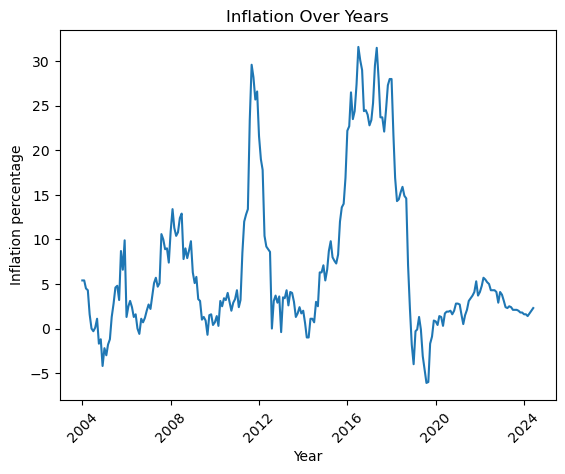

In [29]:
plt.plot(df["Date_transform"], df["Inflation"])

plt.title("Inflation Over Years")
plt.xlabel("Year")
plt.ylabel("Inflation percentage")


plt.xticks(rotation=45)
plt.show()

## General Inflation Trend Analysis
#### Question: Is inflation generally increasing or decreasing?

The line chart shows that inflation rates fluctuate continuously over time, indicating periods of volatility and instability. Therefore, it is difficult to determine directly whether inflation consistently follows an upward or downward trend.

To better identify the overall trend, a `regplot` from the `seaborn` library was used to add a Trend Line, which represents the best fit for the data points.

This trend line helps visualize the general behavior of inflation data over time and provides a clearer indication of whether the overall trend tends to increase or decrease approximately.


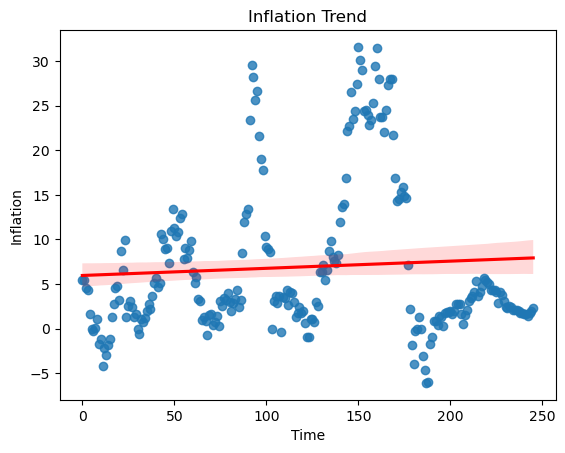

In [30]:
sns.regplot(
    x=np.arange(len(df)),
    y=df["Inflation"],
    line_kws={"color": "red"}
)

plt.title("Inflation Trend")
plt.xlabel("Time")
plt.ylabel("Inflation")

plt.show()

### Conclusion

Based on the trend line, the overall inflation trend appears to be slightly upward over the analyzed period, despite the noticeable fluctuations in inflation rates across different years.

## Step 3: Identifying the Highest and Lowest Inflation Rates

In this step, the maximum and minimum inflation rates in the dataset are identified along with their corresponding dates.

In [31]:
print("The highest Inflation value: ")
max_value = df["Inflation"].idxmax()
print(f"{df["Inflation"].max()}% in {df.loc[max_value, "Date"]}")

print()

print("The lowest Inflation value: ")
min_value = df["Inflation"].idxmin()
print(f"{df["Inflation"].min()}% in {df.loc[min_value, "Date"]}")

The highest Inflation value: 
31.6% in 07/2016

The lowest Inflation value: 
-6.1% in 08/2019


### Step 4: Measuring Month-to-Month Inflation Changes

In this step, a new column called `Change` is created to measure the difference in inflation rates between each month and the previous month.

This calculation helps track how inflation changes over time and highlights periods of sudden increases or decreases in inflation rates.


In [16]:
df["Change"] = df["Inflation"].diff().fillna(0)
df.head()

,Year,Month,Inflation,Change
0,2004,January,5.4,0.0
1,2004,February,5.4,0.0
2,2004,March,4.5,-0.9
3,2004,April,4.3,-0.2
4,2004,May,1.6,-2.7


In [33]:
print("The highest monthly increase: ")
max_increase = df["Change"].idxmax()
print(f"{df["Change"].max():.2f}% in {df.loc[max_increase, "Date"]}")

print()

print("The highest monthly decrease: ")
min_decrease = df["Change"].idxmin()
print(f"{df["Change"].min()}% in {df.loc[min_decrease, "Date"]}")

The highest monthly increase: 
10.00% in 08/2011

The highest monthly decrease: 
-8.6% in 01/2006



### Identifying the Largest Monthly Increase and Decrease

In this section, the monthly changes in inflation rates are visualized using a scatter plot to clearly show the differences between each month and the previous one.

The highest and lowest monthly change values were also identified and highlighted in red to make them easily noticeable within the chart.

This visualization helps in detecting periods that experienced sharp increases or significant decreases in inflation rates.


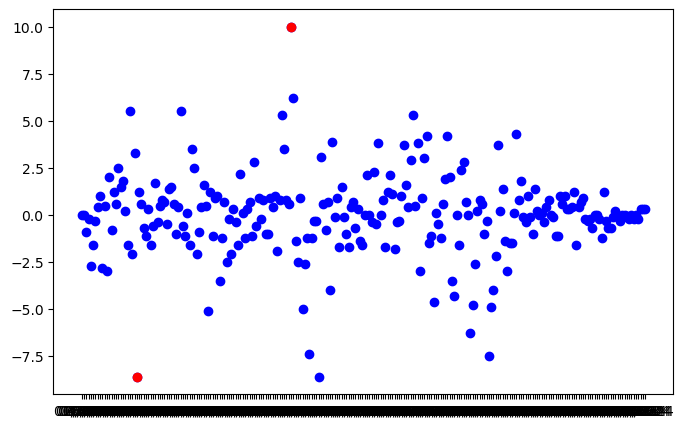

In [34]:
x = df["Date"]
y = df["Change"]

plt.figure(figsize=(8, 5))

plt.scatter(x, y, color="blue")

plt.scatter(
    y.idxmax(),
    y[y.idxmax()],
    color='red',
)

plt.scatter(
    y.idxmin(),
    y[y.idxmin()],
    color='red',
)

### Step 5: Annual Average Inflation Analysis

In this step, the average inflation rate is calculated for each year in the dataset.

By comparing yearly averages, we can identify which year experienced the highest overall inflation and which years were relatively more stable.

In [35]:
inflation_by_year = df["Inflation"].groupby(df["Year"]).mean()
print(inflation_by_year)
print()
print("The highest year Inflation: ")
print(f"{inflation_by_year.idxmax()} --> {inflation_by_year.max():.2f}%")

Year
2004     1.250000
2005     2.808333
2006     1.383333
2007     6.250000
2008    10.450000
2009     2.466667
2010     2.483333
2011    15.841667
2012     9.066667
2013     2.633333
2014     2.391667
2015     9.850000
2016    25.858333
2017    25.816667
2018    13.633333
2019    -2.058333
2020     1.508333
2021     2.875000
2022     4.525000
2023     2.366667
2024     1.766667
Name: Inflation, dtype: float64

The highest year Inflation: 
2016 --> 25.86%


### Step 6: Monthly Inflation Patterns Across All Years

In this step, the average inflation rate is calculated for each month (January, February, March, etc.) across all years in the dataset.

In [36]:
print(df["Inflation"].groupby(df["Month"]).mean().sort_values())

Month
February     6.628571
April        6.633333
March        6.666667
January      6.671429
May          6.714286
June         6.738095
July         6.940000
August       6.980000
November     7.265000
September    7.350000
October      7.380000
December     7.400000
Name: Inflation, dtype: float64



### Monthly Average Inflation Analysis

By calculating the average inflation rate for each month across all years, it can be observed that inflation tends to be relatively lower at the beginning of the year, particularly during the following months:

- January  
- February  
- March  
- April  

After that, the average inflation rate gradually increases as the year progresses, often reaching its highest levels in December.

This pattern may indicate the presence of seasonal or economic factors that contribute to higher price levels toward the end of the year.



### Step 7: Detecting Abnormal Months (Outliers)

In this section, the overall average inflation rate was calculated for the entire dataset in order to establish a reference value representing the general inflation behavior over the studied period.

Each monthly value was then compared against this average, and months where the inflation rate exceeded three times the overall mean were extracted and considered as abnormal values (Outliers).

These outliers highlight extreme inflation events that significantly deviate from the normal behavior of the dataset.


In [37]:
overall = df["Inflation"].mean()
print(f"The overall inflation: {overall:.2f}%")
print()
print(df.loc[df["Inflation"] > overall*3, ["Date", "Inflation"]])

The overall inflation: 6.94%

        Date  Inflation
91   08/2011       23.4
92   09/2011       29.6
93   10/2011       28.2
94   11/2011       25.7
95   12/2011       26.6
96   01/2012       21.6
144  01/2016       22.2
145  02/2016       22.7
146  03/2016       26.5
147  04/2016       23.5
148  05/2016       24.4
149  06/2016       27.4
150  07/2016       31.6
151  08/2016       30.1
152  09/2016       29.0
153  10/2016       24.4
154  11/2016       24.5
155  12/2016       24.0
156  01/2017       22.8
157  02/2017       23.4
158  03/2017       25.3
159  04/2017       29.5
160  05/2017       31.5
161  06/2017       28.0
162  07/2017       23.7
163  08/2017       23.7
164  09/2017       22.1
165  10/2017       24.5
166  11/2017       27.3
167  12/2017       28.0
168  01/2018       28.0
169  02/2018       21.7


### Step 8: Forecasting the Next Month’s Inflation Rate

In this section, a simple forecasting approach is used to estimate the inflation rate for the next month. This is done by calculating the average of the last three available months in the dataset.

The resulting average is then used as the predicted value for the upcoming month, based on the assumption that recent data behavior reflects the near-future trend.

This method provides an approximate forecast that helps in understanding the general direction of inflation. However, it does not rely on advanced predictive models and should be interpreted as a basic estimation.


In [38]:
n = len(df["Date"])
print("The predicted value is: ")
print( df["Inflation"].tail(3).mean() )

The predicted value is: 
2.0
